In [1]:
import logging
import os
import sys
import traceback
import yaml

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

from hydra import initialize, compose
from omegaconf import DictConfig
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import DataLoader, TensorDataset

sys.path.insert(0, "../../../shared_utils")
from experiment_utils import get_forward_model

In [ ]:
adata_loop3 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop3/replicate/adata_500k_residual.h5ad")

## Read anndata

In [2]:
adata_loop3 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop3/replicate/adata_500k_residual.h5ad")

In [3]:
columns_to_keep = [ '740-yp_[µm]',
                    'mtg_[µm]',
                    'rhflt3l_[ng_ml]', 
                    'gm-csf_[ng_ml]',
                    'tpo_[ng_ml]',
                    'sr1_[nm]', 
                    'um171_[nm]', 
                    'um729_[µm]', 
                    'scf_[ng_ml]', 
                    'butyzamide_[nm]',
                    'retinoic_acid_[µm]', 
                    'ldl_[ng_ml]',
                    'il3_[ng_ml]', 
                    'il7_[ng_ml]',
                    'mcsf_[ng_ml]', 
                    'ly_cocktail_[ul/well]',
                    'o2_[%]', 
                  "experiment_number"]

In [4]:
obs_protocols = adata_loop3.obs.loc[:, columns_to_keep]

In [5]:
obs_protocols.drop_duplicates()

,740-yp_[µm],mtg_[µm],rhflt3l_[ng_ml],gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],il7_[ng_ml],mcsf_[ng_ml],ly_cocktail_[ul/well],o2_[%],experiment_number
269705-9,5,100,10,9.2,2.2,997.3,1120.2,0.0,57.2,0.0,0.0,0.1,0.6,0,0.0,1.5,20.0,253
39142-25,5,100,10,10,2.5,750.0,560.0,0.0,10.0,0.0,0.0,0.0,0.0,0,20.0,0.0,20.0,256
202203-34,5,100,10,10,2.5,750.0,560.0,0.0,10.0,0.0,0.0,0.0,0.0,0,2.0,0.0,20.0,257
292145-4,5,100,10,9.2,2.2,997.3,1120.2,0.0,57.2,0.0,0.0,0.1,0.6,0,0.0,15.0,20.0,252
427642-16,5,100,10,10,2.5,750.0,560.0,0.0,10.0,0.0,0.0,0.0,0.0,0,0.0,15.0,20.0,254
426931-18,5,100,10,10,2.5,750.0,560.0,0.0,10.0,0.0,0.0,0.0,0.0,0,0.0,1.5,20.0,255
157117-40,5,100,10,10,2.5,750.0,560.0,0.0,10.0,0.0,0.0,0.0,0.0,0,0.2,0.0,20.0,258


In [6]:
sc.tl.pca(adata_loop3)
sc.pp.neighbors(adata_loop3)
sc.tl.umap(adata_loop3)

## Step 1: Check markers and classify

The goal is to show increase in monocyte and ProB production

In [7]:
adata_loop3.var.index.unique()

Index(['CD49c', 'CD41a', 'CD117', 'CD38', 'HLADR', 'EPCR', 'CD135', 'CD56',
       'CD15', 'CD123', 'CD45', 'CD16', 'CD7', 'CD90', 'CD10', 'CD14',
       'CD45RA', 'CD34', 'CD235a', 'CD19'],
      dtype='object')

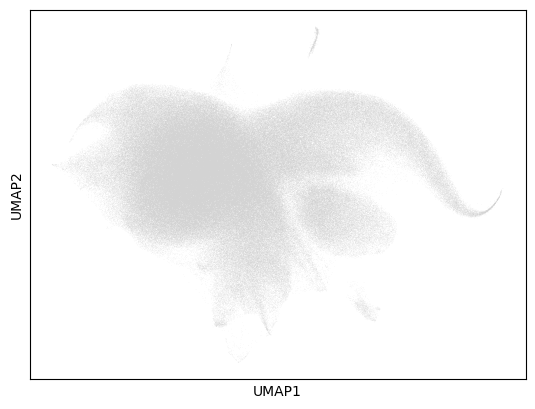

In [8]:
sc.pl.umap(adata_loop3)

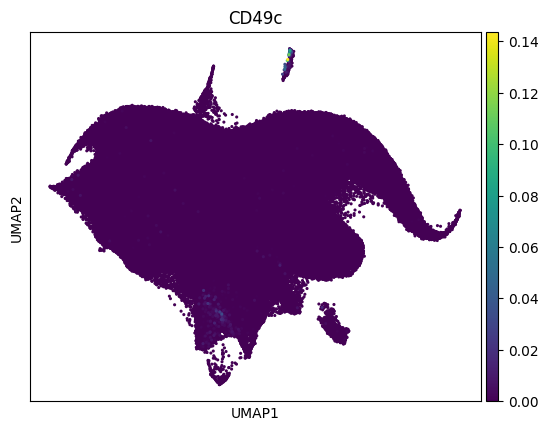

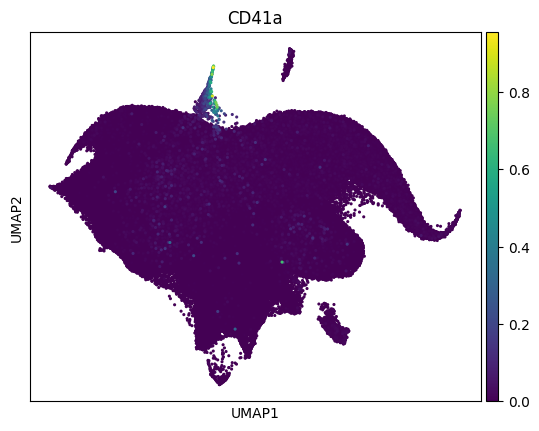

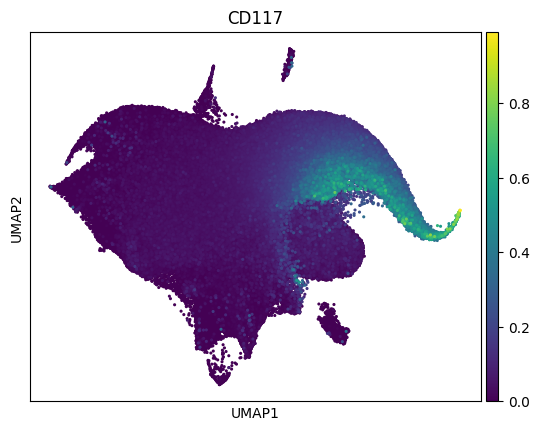

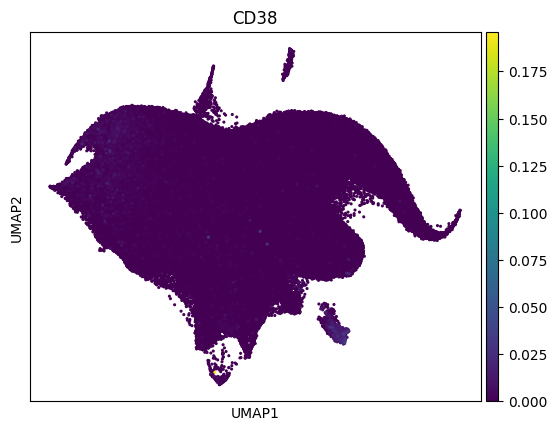

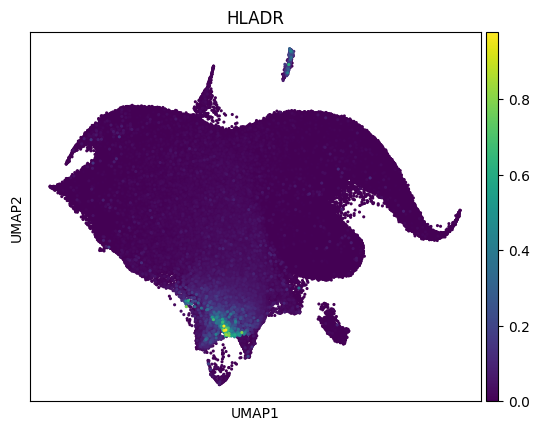

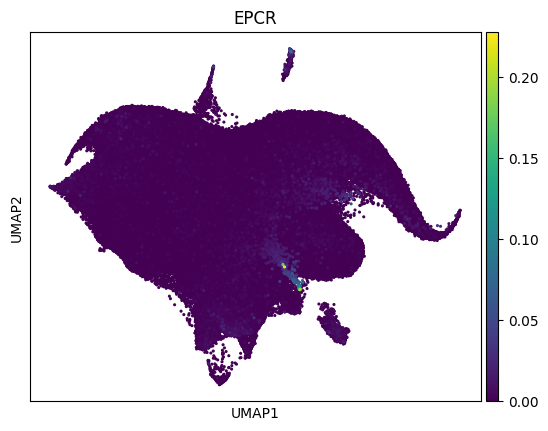

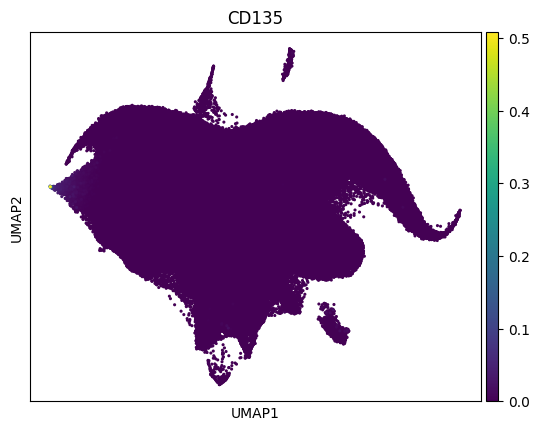

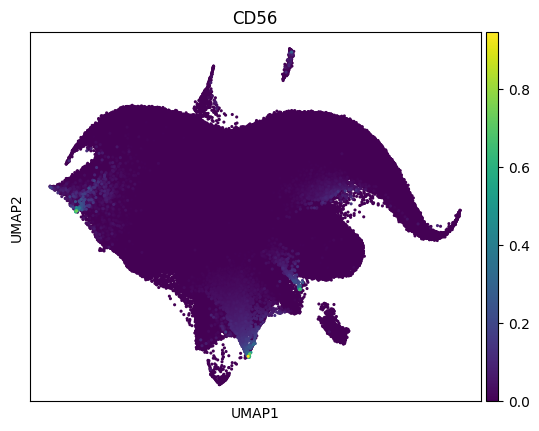

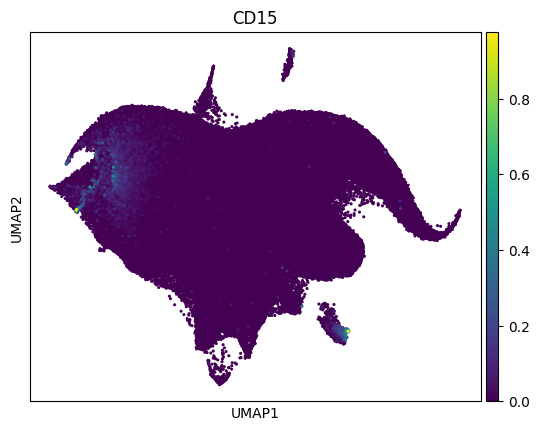

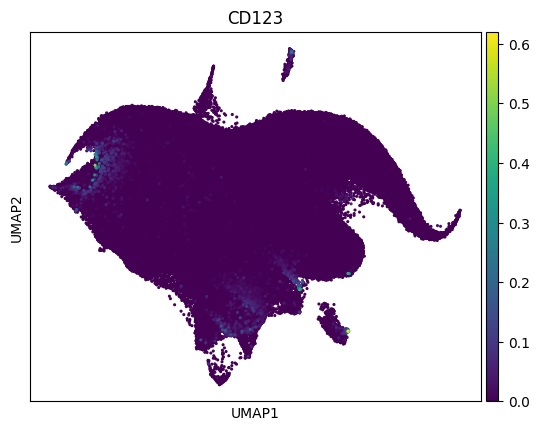

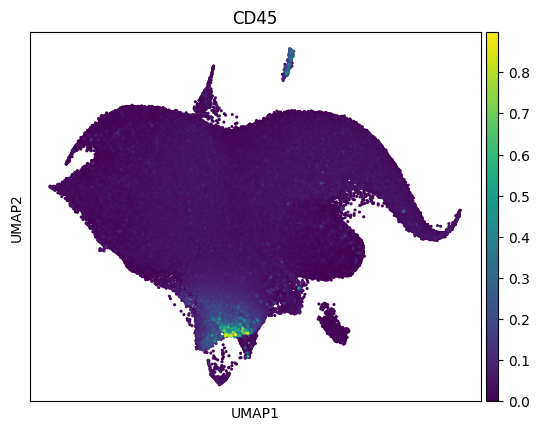

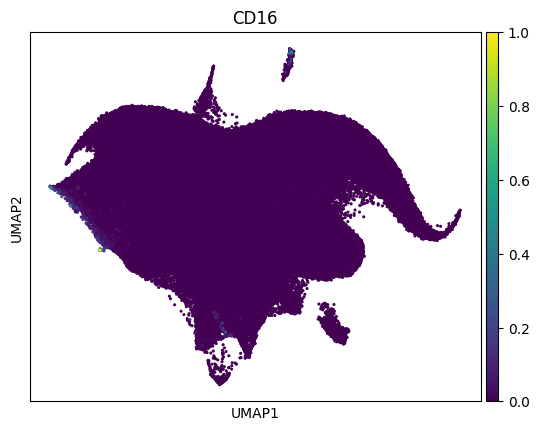

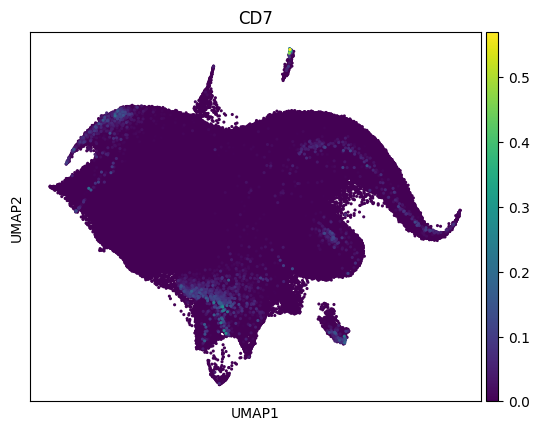

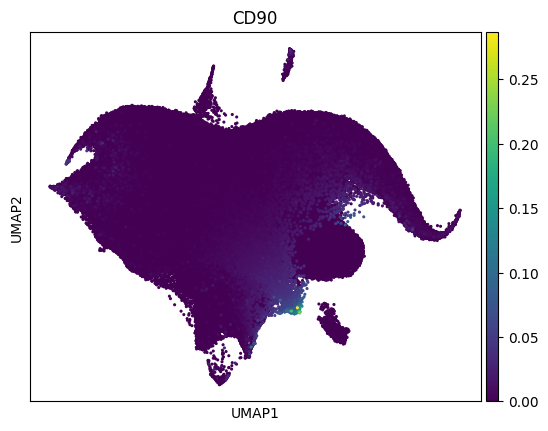

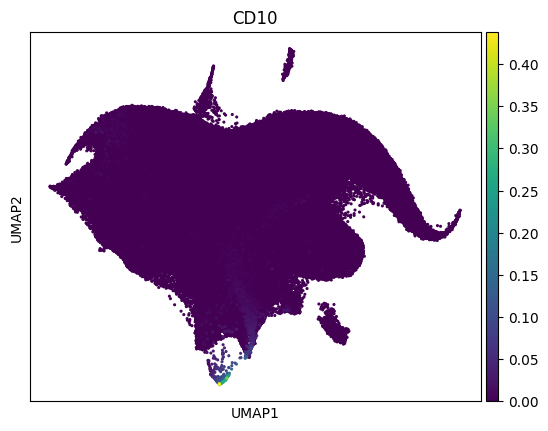

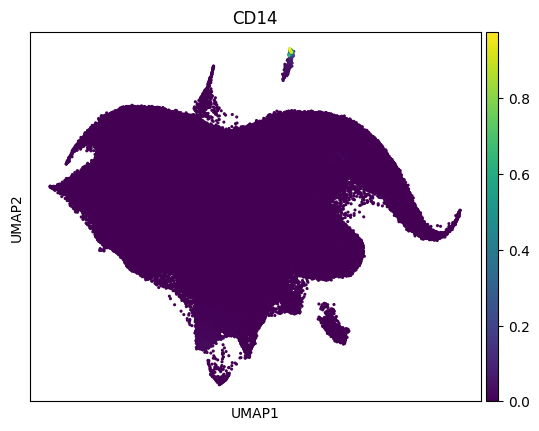

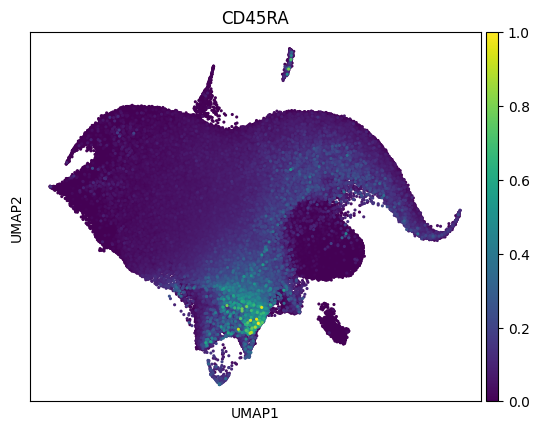

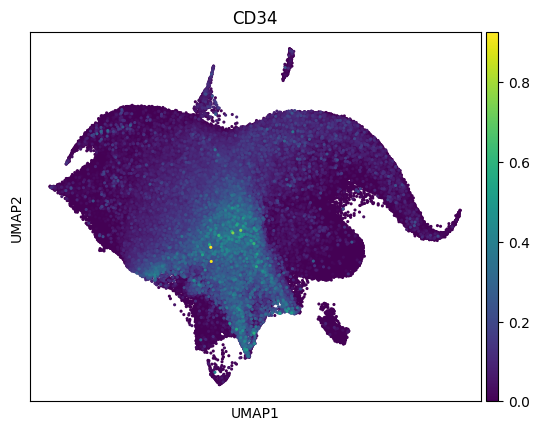

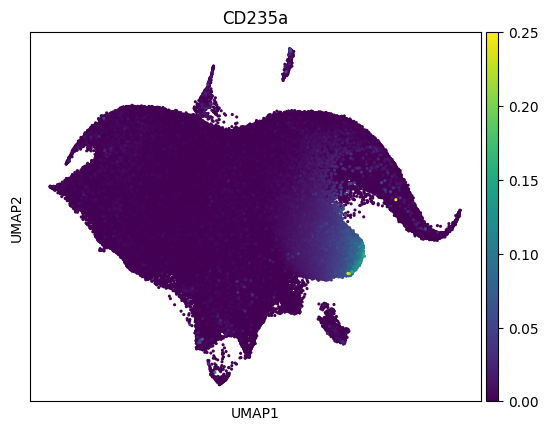

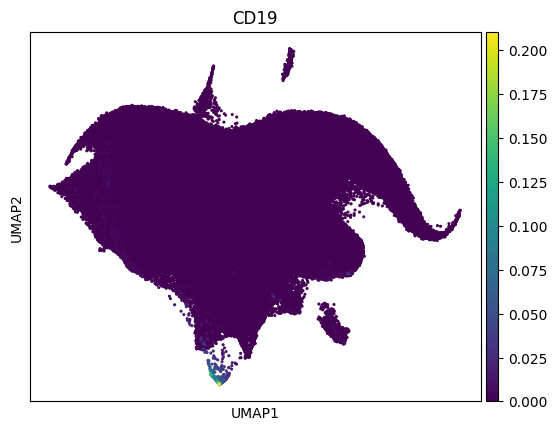

In [9]:
for marker in adata_loop3.var.index:
    sc.pl.umap(adata_loop3, s=20, color=marker)

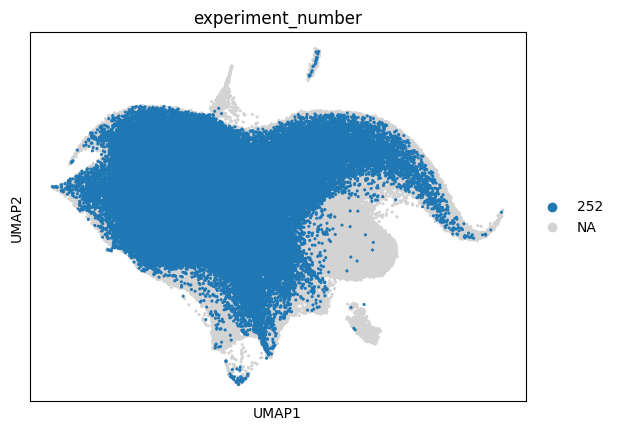

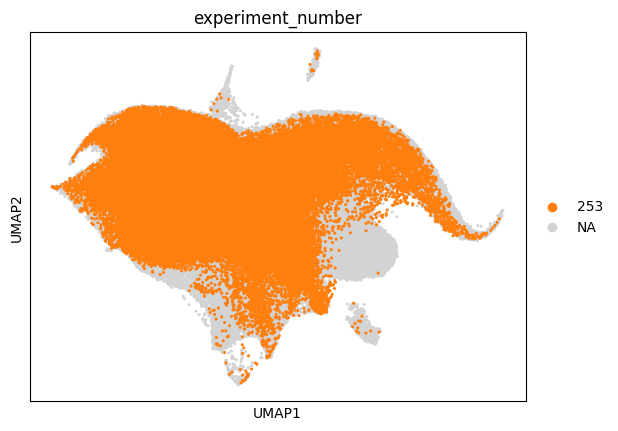

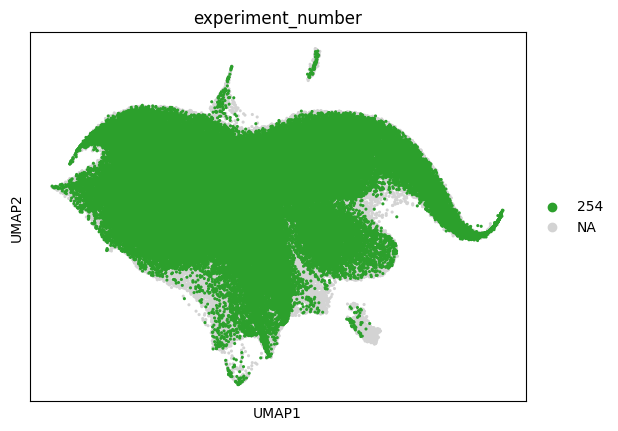

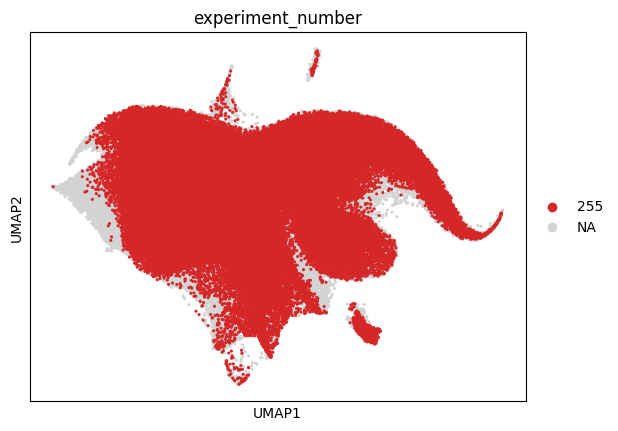

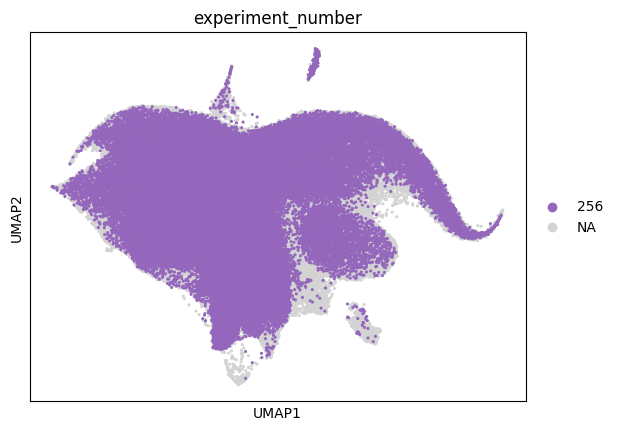

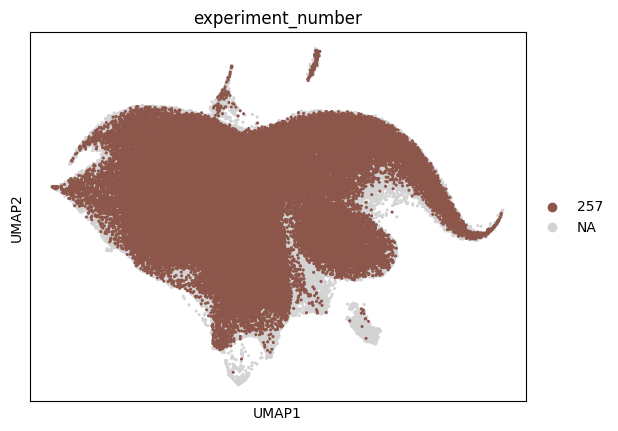

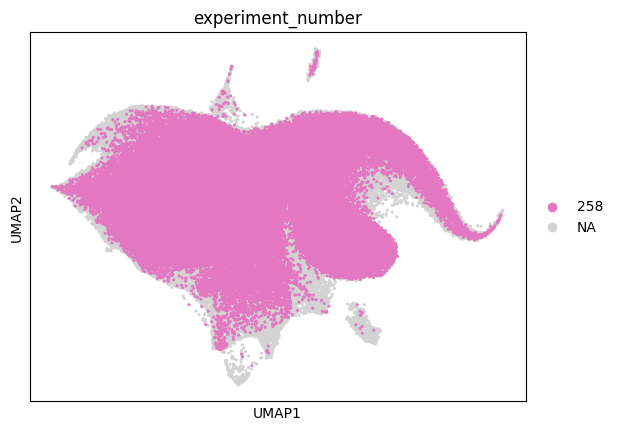

In [10]:
for experiment_no in np.unique(adata_loop3.obs.experiment_number):
    sc.pl.umap(adata_loop3, s=20, color="experiment_number", groups=experiment_no)

Load old classifier and classify

In [11]:
with initialize(config_path="../../../inverse/loss_guidance/config", version_base=None):
    config = compose(config_name="run_inverse",
                    overrides=[
                        "paths=bloodplus_fm", 
                        "annotation=bloodplus"
                    ])

ANNOTATION_CFG_FILE = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/bloodplus_loop3.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]

In [12]:
logger = logging.getLogger(__name__)

forward_model, (
    flow_matching,
    target_prediction_model
) = get_forward_model(config, logger=logger)

In [13]:
train_adata_g = target_prediction_model.train_data.adata
scatter_params = train_adata_g.uns["X_scatter_params"]
channel_params = train_adata_g.uns["X_channel_params"]
scatter_params.keys(), channel_params.keys()

(dict_keys(['mean', 'std']), dict_keys(['mean', 'std']))

In [14]:
X_channel_loop3 = adata_loop3.X

# The model 
X_channel_loop3 = (X_channel_loop3 - channel_params["mean"])/channel_params["std"]

X_scatter_loop3 = []
for col in config.annotation.scatter_columns:
    col_vals_loop3 = adata_loop3.obs[col].astype(float).values
    X_scatter_loop3.append(col_vals_loop3)
    
X_scatter_loop3 = np.stack(X_scatter_loop3, axis=1)
X_scatter_loop3 = (X_scatter_loop3 - scatter_params["mean"])/scatter_params["std"]


X_loop3 = np.concatenate(
    (
        X_channel_loop3, X_scatter_loop3
    ), axis=1
)


print(f"{X_channel_loop3.shape=} {X_scatter_loop3.shape=}")

X_channel_loop3.shape=(499996, 20) X_scatter_loop3.shape=(499996, 6)


In [15]:
dataloader_loop3 = DataLoader(
    torch.utils.data.TensorDataset(torch.from_numpy(X_loop3)), 
    batch_size=4026,
    shuffle=False
)

ct_predictions_loop3 = []

with torch.no_grad():
    for batch in tqdm(dataloader_loop3):
        X_batch = batch[0].to(target_prediction_model.device).to(torch.float32)
        y_pred = target_prediction_model.predict(X_batch)["cell_type"].argmax(1)
        ct_predictions_loop3.append(y_pred.cpu().detach().numpy())
ct_predictions_loop3 = np.concatenate(ct_predictions_loop3)

100%|██████████| 125/125 [00:11<00:00, 10.70it/s]


In [16]:
ct_predictions_loop3

array([ 9, 16, 11, ..., 12, 14,  4], shape=(499996,))

In [17]:
# Prepare label encoder
ct_le = LabelEncoder()
ct_values = train_adata_g.obs["cell_type"].values
ct_le.fit(ct_values)
classes = np.array(ct_le.classes_.tolist())

In [18]:
ct_predictions_str_loop3 = classes[ct_predictions_loop3]

In [19]:
adata_loop3.obs["cell_type"] = ct_predictions_str_loop3

In [20]:
# adata_loop3.write_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop3/replicate/processed/adata_loop3_500k_residual_processed.h5ad")
adata_loop3 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop3/replicate/processed/adata_loop3_500k_residual_processed.h5ad")

/tmp/ipykernel_3717450/3119326320.py:37: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_loop3_plots.obs['cell_type'] = adata_loop3_plots.obs['cell_type'].replace(rename_map)


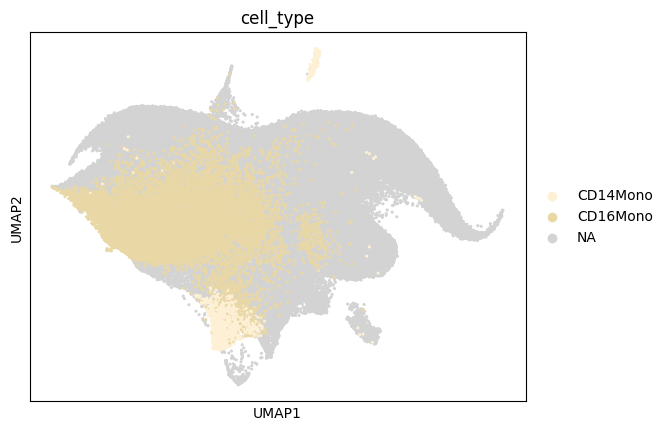

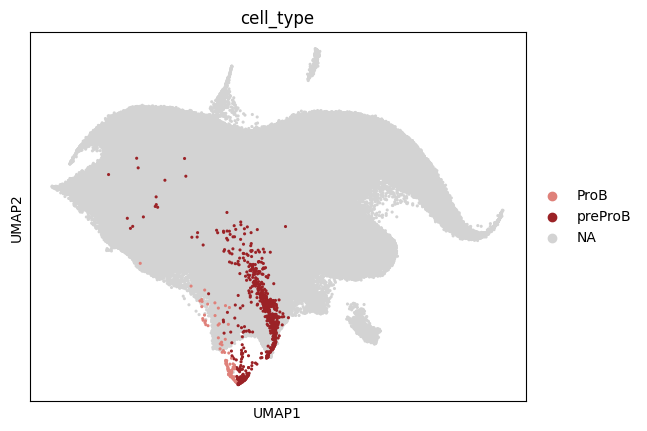

In [21]:
adata_loop3_plots = adata_loop3.copy()

color_map = {
    'HSCs': '#003049',
    'earlyMPP': '#023e8a',
    'MPP': '#005f73',
    'GMP-Neutro': '#0a9396',
    'GMP_cycling': '#1d3557',
    'MPP_MgkEry': '#264653',
    'MgKEryPro1': '#7f908f',
    'MgKEryPro2': '#4a5c6a',
    'MgkPro': '#3a4f6a',
    'EosBasMast1': '#6c757d',
    'EosBasMast2': '#780000',
    'EosBasMast3': '#9d0910',
    'EryPro': '#af0e18',
    'MLP': '#c1121f',
    'LMPP-CLP': '#ae2012',
    'preProB': '#9b2226',
    'ProB': '#df817a',
    'Pre-DC1': '#e76f51',
    'Pre-DC2': '#f4a261',
    'Early_GMP': '#ee9b00',
    'CD14Mono': '#fdf0d5',
    'CD16Mono': '#e9d8a6',
    'CyclingPro1': '#669bbc',
    'CyclingPro2': '#8ecae6',
}

rename_map = {
    "late_MgkPro": "MgkPro",
    "pre_cDC1": "Pre-DC1",
    "pre_cDC2": "Pre-DC2",
}

# Rename cell types
adata_loop3_plots.obs['cell_type'] = adata_loop3_plots.obs['cell_type'].replace(rename_map)

# Build ordered palette matching the cell types present in adata
cell_types = adata_loop3_plots.obs['cell_type'].cat.categories.tolist()
palette = [color_map.get(ct, '#cccccc') for ct in cell_types]

sc.pl.umap(adata_loop3_plots, color="cell_type", s=20, palette=palette, groups=["CD16Mono", "CD14Mono"])
sc.pl.umap(adata_loop3_plots, color="cell_type", s=20, palette=palette, groups=["preProB", "ProB"])

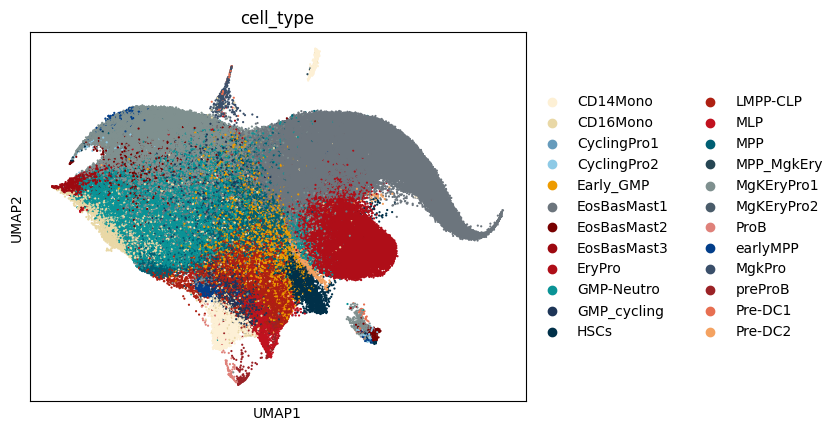

In [22]:
sc.pl.umap(adata_loop3_plots, color="cell_type", s=10)

## Single out protocols

In [21]:
adata_loop3.obs["cell_type"] = adata_loop3.obs["cell_type"].astype("category")

In [24]:
protocols_loop3 = adata_loop3.obs.loc[:, protocol_cols + ["experiment_number"]] 
protocols_loop3 = protocols_loop3.astype(float)

In [25]:
unique_protocols = pd.DataFrame(np.unique(protocols_loop3, axis=0))
unique_protocols.columns = protocols_loop3.columns

unique_protocols = unique_protocols.set_index("experiment_number")
unique_protocols["enriched_ct"] = None

In [26]:
unique_protocols.loc[252, "enriched_ct"] = "preProB_inducing_loop2_ly_15"
unique_protocols.loc[253, "enriched_ct"] = "preProB_inducing_loop2_ly_1p5"
unique_protocols.loc[254, "enriched_ct"] = "preProB_inducing_ly_15"
unique_protocols.loc[255, "enriched_ct"] = "preProB_inducing_ly_1p5"
unique_protocols.loc[256, "enriched_ct"] = "mono_inducing_mcsf_20"
unique_protocols.loc[257, "enriched_ct"] = "mono_inducing_mcsf_2"
unique_protocols.loc[258, "enriched_ct"] = "mono_inducing_mcsf_0p2"

In [27]:
map_prot_to_ct = dict(zip(unique_protocols.index, unique_protocols.enriched_ct))

In [28]:
annot_loop3 = [map_prot_to_ct[float(exp_number)] for exp_number in  adata_loop3.obs.experiment_number]

adata_loop3.obs["Experiment_type"] = annot_loop3

## Plot 

In [29]:
exp_number_ct_prop = {}

In [30]:
for exp_no in np.unique(adata_loop3.obs.experiment_number):
    adata_exp = adata_loop3[adata_loop3.obs.experiment_number==exp_no]
    ct_prop = adata_exp.obs.cell_type.value_counts()
    for ct in classes:
        if ct not in ct_prop.index:
            ct_prop[ct] = 0
    exp_number_ct_prop[exp_no] = ct_prop

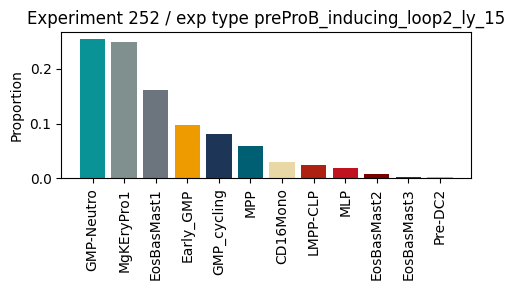

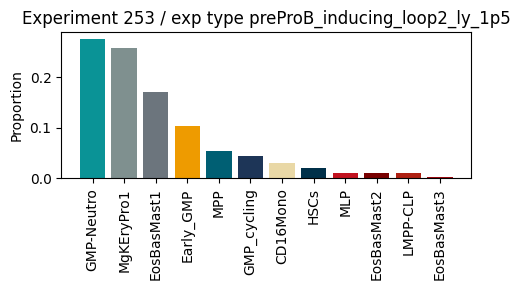

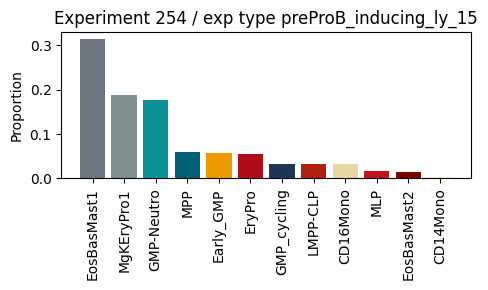

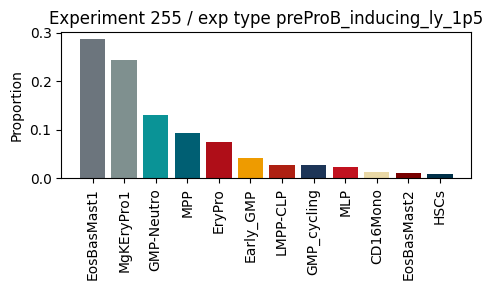

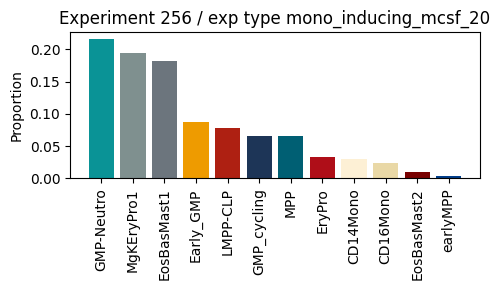

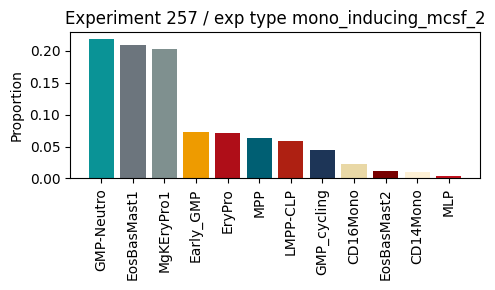

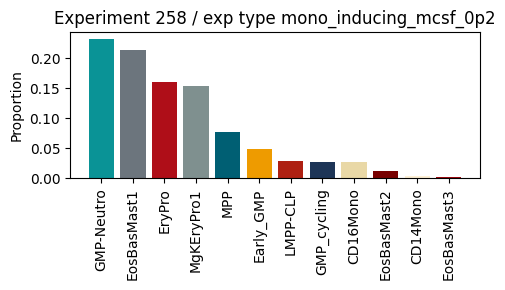

In [31]:
for exp_no in exp_number_ct_prop:
    
    data = exp_number_ct_prop[exp_no]
    # convert to proportions
    prop = data / data.sum()
    
    # Rename cell types
    prop.index = prop.index.map(lambda x: rename_map.get(x, x))
    
    # Keep only top 12 cell types by proportion
    prop = prop.nlargest(12)
    
    # Map colors to the cell types present in this experiment
    colors = [color_map.get(ct, '#cccccc') for ct in prop.index]
    
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.bar(range(len(prop)), prop.values, color=colors)
    ax.set_xticks(range(len(prop)))
    ax.set_xticklabels(prop.index, rotation=90)
    ax.set_ylabel("Proportion")
    ax.set_title(f"Experiment {exp_no} / exp type {map_prot_to_ct[float(exp_no)]}")
    plt.tight_layout()
    
    # Save as SVG in .plots folder
    filename = f"experiment_{exp_no}_ct_proportions.svg"
    # fig.savefig(filename, format='svg', bbox_inches='tight')
    plt.show()
    plt.close(fig)

## Plot markers of interest 

In [32]:
adata_loop1 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop1/adata_500k.h5ad")

In [33]:
import anndata as ad

adata_combined = ad.concat(
    [adata_loop1, adata_loop3])
adata_combined.obs["experiment_number"] = adata_combined.obs["experiment_number"].astype(str)
adata_combined.obs["count_beads"] = adata_combined.obs["count_beads"].astype(str)
adata_combined.obs["cell_counts"] = adata_combined.obs["count_beads"].astype(int)

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


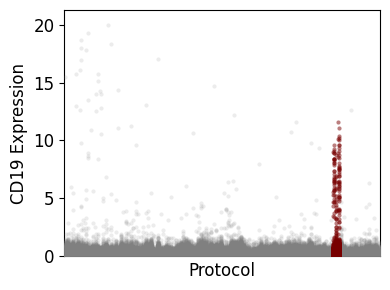

In [34]:
plot_df = adata_combined.obs[['experiment_number']].copy().astype("category")
plot_df['CD19'] = adata_combined[:, 'CD19'].X.toarray().flatten()
to_exclude = ["255", "257", "258"]
to_highlight = ["252", "253", "254", "255"]

# Filter rows
plot_df = plot_df[~plot_df["experiment_number"].isin(to_exclude)]

# Remove unused categorical levels
plot_df["experiment_number"] = (
    plot_df["experiment_number"]
    .cat.remove_unused_categories()
)
# Create color grouping
plot_df["group"] = np.where(
    plot_df["experiment_number"].isin(to_highlight),
    "highlight",
    "other"
)
fig, ax = plt.subplots(figsize=(4, 3))
sns.stripplot(
    data=plot_df[plot_df["group"] == "other"],
    x="experiment_number",
    y="CD19",
    color="gray",
    alpha=0.15,
    size=3,
    dodge=False,
    ax=ax
)
sns.stripplot(
    data=plot_df[plot_df["group"] == "highlight"],
    x="experiment_number",
    y="CD19",
    color="#780000",
    alpha=0.5,
    size=3,
    dodge=False,
    ax=ax
)
ax.set_xlabel("Protocol", fontsize=12)
ax.set_ylabel("CD19 Expression", fontsize=12)
ax.set_xticks([])
ax.tick_params(axis='y', labelsize=12)
ax.set_ylim(bottom=0)
plt.tight_layout()
# fig.savefig(
#     "CD41a_vs_others.png",
#     format='png',
#     dpi=500,
#     bbox_inches='tight'
# )
plt.show()
plt.close(fig)

Ask about il7

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


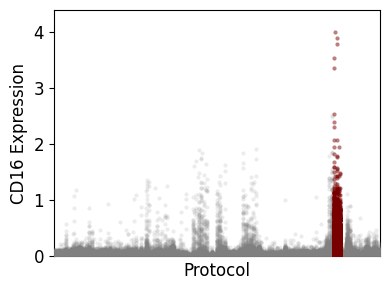

In [35]:
plot_df = adata_combined.obs[['experiment_number']].copy().astype("category")
plot_df['CD16'] = adata_combined[:, 'CD16'].X.toarray().flatten()
to_exclude = ["252", "253", "254", "255"]
to_highlight = ["256", "257", "258"]

# Filter rows
plot_df = plot_df[~plot_df["experiment_number"].isin(to_exclude)]

# Remove unused categorical levels
plot_df["experiment_number"] = (
    plot_df["experiment_number"]
    .cat.remove_unused_categories()
)
# Create color grouping
plot_df["group"] = np.where(
    plot_df["experiment_number"].isin(to_highlight),
    "highlight",
    "other"
)
fig, ax = plt.subplots(figsize=(4, 3))
sns.stripplot(
    data=plot_df[plot_df["group"] == "other"],
    x="experiment_number",
    y="CD16",
    color="gray",
    alpha=0.15,
    size=3,
    dodge=False,
    ax=ax
)
sns.stripplot(
    data=plot_df[plot_df["group"] == "highlight"],
    x="experiment_number",
    y="CD16",
    color="#780000",
    alpha=0.5,
    size=3,
    dodge=False,
    ax=ax
)
ax.set_xlabel("Protocol", fontsize=12)
ax.set_ylabel("CD16 Expression", fontsize=12)
ax.set_xticks([])
ax.tick_params(axis='y', labelsize=12)
ax.set_ylim(bottom=0)
plt.tight_layout()
# fig.savefig(
#     "CD41a_vs_others.png",
#     format='png',
#     dpi=500,
#     bbox_inches='tight'
# )
plt.show()
plt.close(fig)

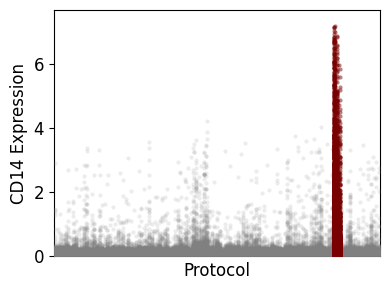

In [36]:
plot_df = adata_combined.obs[['experiment_number']].copy().astype("category")
plot_df['CD14'] = adata_combined[:, 'CD14'].X.toarray().flatten()
to_exclude = ["252", "253", "254", "255"]
to_highlight = ["256", "257", "258"]

# Filter rows
plot_df = plot_df[~plot_df["experiment_number"].isin(to_exclude)]

# Remove unused categorical levels
plot_df["experiment_number"] = (
    plot_df["experiment_number"]
    .cat.remove_unused_categories()
)
# Create color grouping
plot_df["group"] = np.where(
    plot_df["experiment_number"].isin(to_highlight),
    "highlight",
    "other"
)
fig, ax = plt.subplots(figsize=(4, 3))
sns.stripplot(
    data=plot_df[plot_df["group"] == "other"],
    x="experiment_number",
    y="CD14",
    color="gray",
    alpha=0.15,
    size=3,
    dodge=False,
    ax=ax
)
sns.stripplot(
    data=plot_df[plot_df["group"] == "highlight"],
    x="experiment_number",
    y="CD14",
    color="#780000",
    alpha=0.5,
    size=3,
    dodge=False,
    ax=ax
)
ax.set_xlabel("Protocol", fontsize=12)
ax.set_ylabel("CD14 Expression", fontsize=12)
ax.set_xticks([])
ax.tick_params(axis='y', labelsize=12)
ax.set_ylim(bottom=0)
plt.tight_layout()
# fig.savefig(
#     "CD41a_vs_others.png",
#     format='png',
#     dpi=500,
#     bbox_inches='tight'
# )
plt.show()
plt.close(fig)

In [37]:
plot_df.drop("group", axis=1).groupby("experiment_number").max().sort_values(by="CD14", ascending=False)

/tmp/ipykernel_3717450/202863778.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df.drop("group", axis=1).groupby("experiment_number").max().sort_values(by="CD14", ascending=False)


,CD14
experiment_number,
256,7.191304
257,6.858308
258,5.953490
1178,4.228848
208,4.047719
...,...
110,0.502339
41,0.500490
1146,0.453794


## Now concatenate data frames for training 

In [ ]:
# import scanpy as sc
# import numpy as np
# import anndata as ad

In [54]:
# adata_loop_2p5_500k = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop2p5/replicate/adata_500k.h5ad")
# adata_loop_2p5 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop2p5/replicate/adata_full.h5ad")

In [55]:
# adata_loop_2p5

In [56]:
# adata_loop_2p5_500k

In [57]:
# # ---- Load 500k subset ----
# adata_loop3_500k_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop3/replicate/adata_500k_residual.h5ad"
# adata_loop3_500k = sc.read_h5ad(adata_loop3_500k_path)
# print(f"{adata_loop3_500k=}")

# # ---- Load 500k subset ----
# adata_loop3_full_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop3/replicate/adata_full_residual.h5ad"
# adata_loop3_full = sc.read_h5ad(adata_loop3_full_path)
# print(f"{adata_loop3_full=}")

In [58]:
# adata_loop3_500k.obs['ly_cocktail_[ul/well]'].max()

In [59]:
# adata_loop3_full.obs['ly_cocktail_[ul/well]'].max()

In [60]:
# residual_ingredients = ['il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]']

In [61]:
# for residual_ingredient in residual_ingredients:
#     print(residual_ingredient in adata_loop3_full.obs.columns)

In [62]:
# for residual_ingredient in residual_ingredients:
#     print(residual_ingredient in adata_loop_2p5.obs.columns)

Add columns to obs as zeros 

In [63]:
# adata_loop_2p5.obs.loc[:, residual_ingredients] = 0
# adata_loop_2p5_500k.obs.loc[:, residual_ingredients] = 0

In [64]:
# for residual_ingredient in residual_ingredients:
#     print(residual_ingredient in adata_loop_2p5.obs.columns)

In [65]:
# np.setdiff1d(adata_loop3_500k.obs.columns, adata_loop_2p5_500k.obs.columns)

In [66]:
# np.setdiff1d(adata_loop3_full.obs.columns, adata_loop_2p5.obs.columns)

In [67]:
# ---- Concatenate 500k subset ----
# adata_loop3_concat_500k = ad.concat((adata_loop_2p5_500k, adata_loop3_500k), merge="same", uns_merge="same")
# adata_loop3_concat_500k.obs_names_make_unique()
# print(f"{adata_loop3_concat_500k=}")

# # ---- Concatenate full data ----
# adata_loop3_concat_full = ad.concat((adata_loop_2p5, adata_loop3_full), merge="same", uns_merge="same")
# adata_loop3_concat_full.obs_names_make_unique()
# print(f"{adata_loop3_concat_full=}")

In [68]:
# import os 
# loop3_dump_dir = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop3/replicate"
# loop3_500k_out_path = os.path.join(loop3_dump_dir, "adata_500k.h5ad") # concatenated adata (500k)
# loop3_full_out_path = os.path.join(loop3_dump_dir, "adata_full.h5ad") # concatenate adata (full)

In [69]:
# # ---- Define function for sanitizing adata ----
# def sanitize_anndata(adata: ad.AnnData, convert_to: str = "string") -> ad.AnnData:
#     for df, name in [(adata.obs, "obs"), (adata.var, "var")]:
#         for col in df.columns:
#             if df[col].dtype == "object":
#                 if convert_to == "string":
#                     # Convert to pandas nullable string dtype (safe for HDF5 writing)
#                     df[col] = df[col].astype("string")
#                 elif convert_to == "category":
#                     df[col] = df[col].astype("category")
#                 else:
#                     raise ValueError("convert_to must be 'string' or 'category'")
#     return adata

In [70]:
# adata_loop3_concat_500k = sanitize_anndata(adata_loop3_concat_500k)
# adata_loop3_concat_full = sanitize_anndata(adata_loop3_concat_full)

# adata_loop3_concat_500k.write_h5ad(loop3_500k_out_path)
# adata_loop3_concat_full.write_h5ad(loop3_full_out_path)